# Chapter 9: Video Understanding — Spatio-Temporal Transformers

*Build a Multimodal Model from Scratch*

---

**What you will build in this chapter**

By the end, you will have a working **VideoTransformer** that classifies synthetic videos
using tubelet embeddings and factorized spatio-temporal attention — the same architecture
family as **ViViT** (Video Vision Transformer).

We solve four concrete problems in order:

| # | Problem | Solution |
|---|---------|----------|
| 1 | Video = Images + Time. What changes? | Model spatial AND temporal patterns jointly |
| 2 | How do we embed spatio-temporal patches? | Tubelet embedding: Conv3d across (t, h, w) |
| 3 | How do we handle attention across T×H×W tokens? | Factorized attention: spatial then temporal |
| 4 | How do we connect video to the multimodal pipeline? | Temporal pooling → classifier or LLM |


> **This chapter in context:** Ch09 adds the time dimension to the spatial ViT from Ch01 by stacking video frames as a 3-D patch volume (tubelet embedding). Factorised spatial + temporal attention keeps the token count tractable. Like Ch08 (audio), the VideoTransformer here is a drop-in encoder for the VLM in Ch03 — just replace the ViT with a VideoTransformer and pass video clips instead of still images. This architecture is the basis of ViViT, Video-LLaVA, and VideoChat.

In [1]:
%matplotlib inline
import os, math, random, uuid, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, Rectangle, FancyBboxPatch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ─────────────────────────────────────────────────────────
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')


Device: cpu


---
## Problem 1 — Video = Images + Time. What changes?

A video is a sequence of frames. Instead of a single image tensor `(C, H, W)`,
we now have `(C, T, H, W)` where **T is the time dimension**.

**The naive approach** — process each frame independently with ViT — fails to capture
temporal motion. A rotating circle *looks like a static circle* frame-by-frame.
A blinking image would appear identical across frames if we only look at individual frames.

**What we need:**
- Spatial attention: which pixels go together *within* a frame
- Temporal attention: how does a region *change across frames*
- Both simultaneously: the full spatio-temporal context

The core tensor layout change:

```
Image   : (B, C,    H, W)       → spatial only
Video   : (B, C, T, H, W)       → spatial + temporal
```


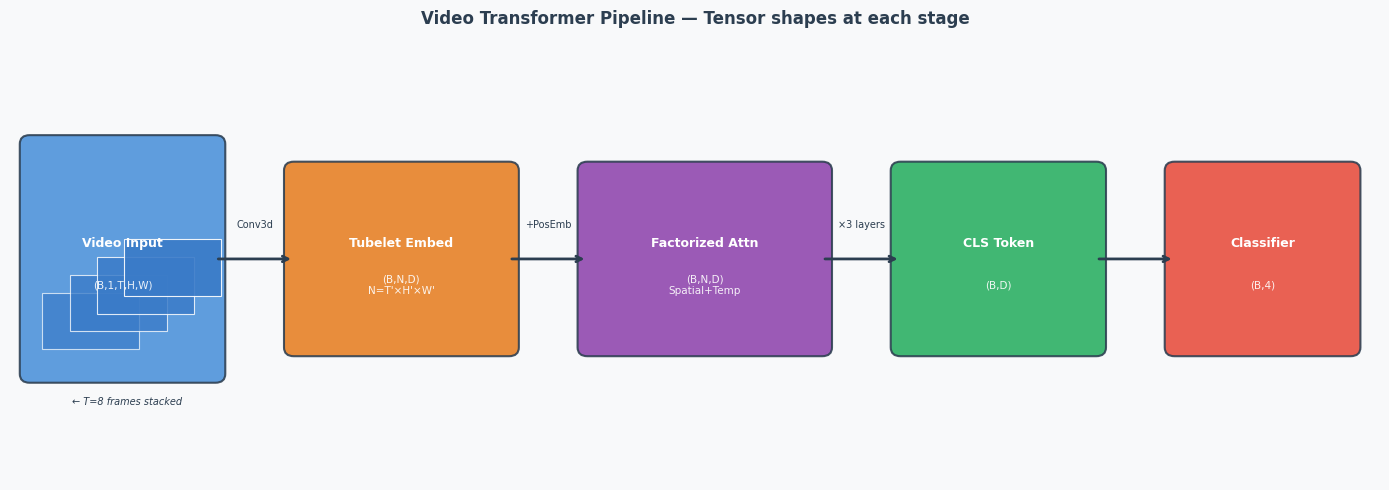

In [2]:
def draw_video_pipeline():
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 5)
    ax.axis('off')

    def box(x, y, w, h, color, label, sublabel='', fontsize=9):
        rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                               facecolor=color, edgecolor=PAL['dark'],
                               linewidth=1.5, alpha=0.88)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2 + (0.18 if sublabel else 0), label,
                ha='center', va='center', fontsize=fontsize, fontweight='bold',
                color='white')
        if sublabel:
            ax.text(x + w/2, y + h/2 - 0.3, sublabel,
                    ha='center', va='center', fontsize=7.5, color='white', alpha=0.9)

    def arrow(x1, x2, y=2.5, lbl=''):
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=2))
        if lbl:
            ax.text((x1 + x2) / 2, y + 0.35, lbl,
                    ha='center', fontsize=7, color=PAL['dark'])

    # Stage boxes
    box(0.2, 1.2, 1.9, 2.6, PAL['blue'],   'Video Input',   '(B,1,T,H,W)')
    arrow(2.1, 2.9, lbl='Conv3d')
    box(2.9, 1.5, 2.2, 2.0, PAL['orange'], 'Tubelet Embed', '(B,N,D)\nN=T\'×H\'×W\'')
    arrow(5.1, 5.9, lbl='+PosEmb')
    box(5.9, 1.5, 2.4, 2.0, PAL['purple'], 'Factorized Attn', '(B,N,D)\nSpatial+Temp')
    arrow(8.3, 9.1, lbl='×3 layers')
    box(9.1, 1.5, 2.0, 2.0, PAL['green'],  'CLS Token',     '(B,D)')
    arrow(11.1, 11.9)
    box(11.9, 1.5, 1.8, 2.0, PAL['red'],   'Classifier',    '(B,4)')

    # Draw stacked frames schematically inside the Input box
    for i in range(4):
        mini = FancyBboxPatch((0.35 + i * 0.28, 1.5 + i * 0.2), 0.95, 0.6,
                               boxstyle='square,pad=0.02',
                               facecolor='#3A7BC8', edgecolor='white',
                               linewidth=0.8, alpha=0.7 + 0.07 * i)
        ax.add_patch(mini)
    ax.text(1.2, 0.85, '← T=8 frames stacked', ha='center', fontsize=7,
            color=PAL['dark'], style='italic')

    ax.set_title('Video Transformer Pipeline — Tensor shapes at each stage',
                 fontsize=12, fontweight='bold', color=PAL['dark'], pad=10)
    plt.tight_layout()
    plt.show()

draw_video_pipeline()


---
## Problem 2 — How do we embed spatio-temporal patches?

In a standard ViT we use **PatchEmbedding** — a `Conv2d` that cuts each frame into
non-overlapping 2D patches and projects them to dimension D.

For video we have two options:

| Option | Idea | Trade-off |
|--------|------|-----------|
| **A: Tubelet** | `Conv3d` across `(t, h, w)` — each tube spans multiple frames | More principled, captures local motion |
| **B: Frame-by-frame** | Apply ViT per frame, add temporal position embedding | Simpler, but no cross-frame local encoding |

We implement **Option A (Tubelet)** because it is more principled.
Each tubelet is like a little 3D brick cut from the video volume.

With `T=8`, `img_size=32`, `t_patch=2`, `h_patch=8`, `w_patch=8`:
```
N_t = 8/2 = 4,   N_h = 32/8 = 4,   N_w = 32/8 = 4
N_total = 4 × 4 × 4 = 64 tokens
```


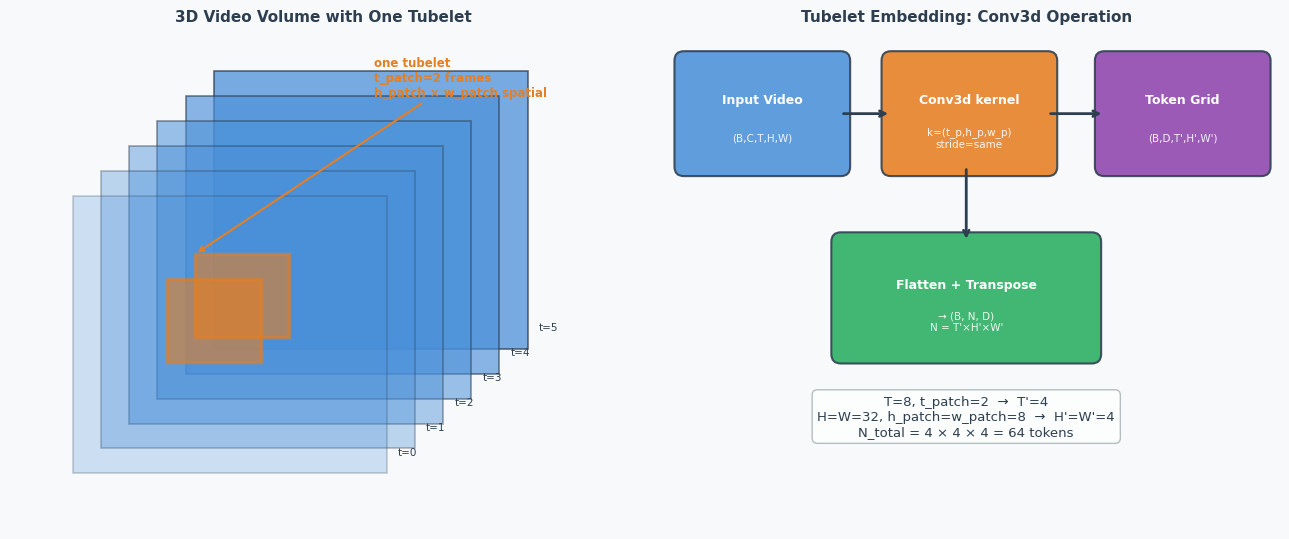

In [3]:
def draw_tubelet_embedding():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.patch.set_facecolor(PAL['bg'])

    # ── Left: 3D video volume with tubelet highlighted ──────────────────────
    ax = axes[0]
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(-1, 9)
    ax.set_ylim(-1, 8)
    ax.axis('off')
    ax.set_title('3D Video Volume with One Tubelet', fontsize=11,
                 fontweight='bold', color=PAL['dark'])

    n_frames = 6
    for i in range(n_frames - 1, -1, -1):
        ox, oy = i * 0.45, i * 0.45
        alpha = 0.25 + 0.1 * i
        rect = Rectangle((ox, oy), 5, 5, linewidth=1.2,
                          edgecolor=PAL['dark'], facecolor=PAL['blue'], alpha=alpha)
        ax.add_patch(rect)
        ax.text(ox + 5.18, oy + 0.3, f't={i}', fontsize=7.5,
                color=PAL['dark'], va='bottom')

    # Highlight one tubelet in orange (2 frames, spatial patch)
    for i in [0, 1]:
        ox, oy = i * 0.45, i * 0.45
        tube = Rectangle((ox + 1.5, oy + 2.0), 1.5, 1.5,
                          linewidth=2.5, edgecolor=PAL['orange'],
                          facecolor=PAL['orange'], alpha=0.6)
        ax.add_patch(tube)

    ax.annotate('one tubelet\nt_patch=2 frames\nh_patch × w_patch spatial',
                xy=(1.5 + 0.45, 2.0 + 0.45 + 1.5),
                xytext=(4.8, 6.8),
                fontsize=8.5, color=PAL['orange'], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=PAL['orange'], lw=1.5))

    # ── Right: Conv3d math ───────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor(PAL['bg'])
    ax2.axis('off')
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 8)
    ax2.set_title('Tubelet Embedding: Conv3d Operation', fontsize=11,
                  fontweight='bold', color=PAL['dark'])

    def box2(x, y, w, h, color, label, sub=''):
        r = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                            facecolor=color, edgecolor=PAL['dark'],
                            linewidth=1.5, alpha=0.88)
        ax2.add_patch(r)
        ax2.text(x + w/2, y + h/2 + (0.22 if sub else 0), label,
                 ha='center', va='center', fontsize=9,
                 fontweight='bold', color='white')
        if sub:
            ax2.text(x + w/2, y + h/2 - 0.38, sub,
                     ha='center', va='center', fontsize=7.5,
                     color='white', alpha=0.9)

    box2(0.5, 5.8, 2.5, 1.7, PAL['blue'],   'Input Video',   '(B,C,T,H,W)')
    ax2.annotate('', xy=(3.8, 6.65), xytext=(3.0, 6.65),
                 arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=2))
    box2(3.8, 5.8, 2.5, 1.7, PAL['orange'], 'Conv3d kernel',
         f'k=(t_p,h_p,w_p)\nstride=same')
    ax2.annotate('', xy=(7.2, 6.65), xytext=(6.3, 6.65),
                 arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=2))
    box2(7.2, 5.8, 2.5, 1.7, PAL['purple'], 'Token Grid',    "(B,D,T',H',W')")

    box2(3.0, 2.8, 4.0, 1.8, PAL['green'],  'Flatten + Transpose',
         '→ (B, N, D)\nN = T\'×H\'×W\'')
    ax2.annotate('', xy=(5.0, 4.6), xytext=(5.0, 5.8),
                 arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=2))

    ax2.text(5.0, 1.8,
             'T=8, t_patch=2  →  T\'=4\n'
             'H=W=32, h_patch=w_patch=8  →  H\'=W\'=4\n'
             'N_total = 4 × 4 × 4 = 64 tokens',
             ha='center', va='center', fontsize=9.5,
             color=PAL['dark'],
             bbox=dict(facecolor='white', edgecolor=PAL['grey'],
                       boxstyle='round,pad=0.4', alpha=0.7))

    plt.tight_layout()
    plt.show()

draw_tubelet_embedding()


In [4]:
class TubeletEmbedding(nn.Module):
    """
    3D patch embedding for video: extends 2D PatchEmbedding to the time dimension.

    Input : (B, C, T, H, W)
    Output: (B, N_total, D)  where N_total = (T/t_patch) * (H/h_patch) * (W/w_patch)

    Compare with 2D version:
      PatchEmbedding : Conv2d(C, D, kernel_size=(h,w), stride=(h,w))
      TubeletEmbedding: Conv3d(C, D, kernel_size=(t,h,w), stride=(t,h,w))
    """
    def __init__(self, in_channels: int, embed_dim: int,
                 t_patch: int = 2, h_patch: int = 8, w_patch: int = 8):
        super().__init__()
        self.proj = nn.Conv3d(
            in_channels, embed_dim,
            kernel_size=(t_patch, h_patch, w_patch),
            stride=(t_patch, h_patch, w_patch)
        )
        self.t_patch = t_patch
        self.h_patch = h_patch
        self.w_patch = w_patch

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T, H, W)
        x = self.proj(x)           # (B, D, T', H', W')  where T'=T/t_patch etc.
        B, D, T, H, W = x.shape
        x = x.flatten(2)           # (B, D, T'*H'*W')
        x = x.transpose(1, 2)     # (B, T'*H'*W', D)  — standard sequence-first layout
        return x


# ── Shape verification ───────────────────────────────────────────────────────
emb = TubeletEmbedding(in_channels=1, embed_dim=64, t_patch=2, h_patch=8, w_patch=8)
dummy = torch.zeros(2, 1, 8, 32, 32)   # B=2, C=1, T=8, H=32, W=32
out   = emb(dummy)
print(f'Input shape : {tuple(dummy.shape)}')
print(f'Output shape: {tuple(out.shape)}')
print(f'Expected tokens: (8/2)×(32/8)×(32/8) = 4×4×4 = {4*4*4}')
assert out.shape == (2, 64, 64), f'Unexpected shape: {out.shape}'
print('Shape check PASSED ✓')


Input shape : (2, 1, 8, 32, 32)
Output shape: (2, 64, 64)
Expected tokens: (8/2)×(32/8)×(32/8) = 4×4×4 = 64
Shape check PASSED ✓


---
## Problem 3 — How do we handle attention across T×H×W tokens?

With T=8 frames and 4×4 spatial patches, we get **64 tokens**.
Full 3D self-attention would cost **O(64²) = 4,096** per layer.
For larger videos (224×224 frames, 32 frames) this explodes to millions of operations.

**Factorized attention (ViViT Model 3)** decomposes the problem:

| Attention type | Attends over | Cost per layer |
|----------------|-------------|----------------|
| Spatial | All H'×W' patches in *one* frame | O((H'×W')²) × T |
| Temporal | Same spatial pos, across all T frames | O(T²) × H'×W' |
| Full 3D | All T×H'×W' tokens | O((T×H'×W')²) |

Our config: T=4 temporal tokens, H'=W'=4 spatial → 16 spatial tokens per frame

```
Factorized: 16² × 4 + 4² × 16 =  1,024 + 256 =  1,280
Full 3D   : 64²                           =          4,096  (3.2× more)
```

The savings grow quadratically with scale.


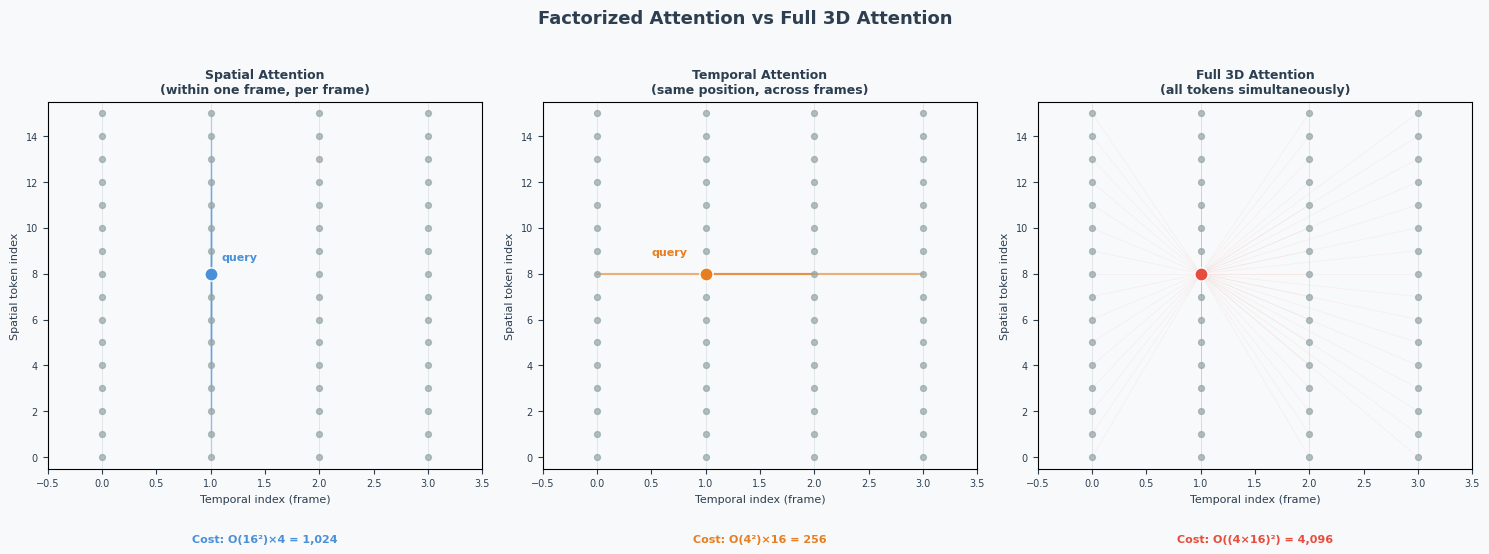

In [5]:
def draw_factorized_attention():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
    fig.patch.set_facecolor(PAL['bg'])
    fig.suptitle('Factorized Attention vs Full 3D Attention',
                 fontsize=13, fontweight='bold', color=PAL['dark'], y=1.02)

    T_frames, N_spatial = 4, 16

    for ax_idx, (ax, title, color) in enumerate(zip(
        axes,
        ['Spatial Attention\n(within one frame, per frame)',
         'Temporal Attention\n(same position, across frames)',
         'Full 3D Attention\n(all tokens simultaneously)'],
        [PAL['blue'], PAL['orange'], PAL['red']]
    )):
        ax.set_facecolor(PAL['bg'])
        ax.set_xlim(-0.5, T_frames - 0.5)
        ax.set_ylim(-0.5, N_spatial - 0.5)
        ax.set_title(title, fontsize=9, fontweight='bold', color=PAL['dark'], pad=6)
        ax.set_xlabel('Temporal index (frame)', fontsize=8, color=PAL['dark'])
        ax.set_ylabel('Spatial token index', fontsize=8, color=PAL['dark'])
        ax.tick_params(labelsize=7, colors=PAL['dark'])

        # Draw frame separators
        for t in range(T_frames):
            ax.axvline(t, color=PAL['grey'], lw=0.4, alpha=0.4)

        # Draw all tokens
        for t in range(T_frames):
            for s in range(N_spatial):
                ax.scatter(t, s, c=PAL['grey'], s=18, zorder=2, alpha=0.7)

        q_t, q_s = 1, 8

        if ax_idx == 0:   # Spatial: query attends all tokens in same frame
            for s in range(N_spatial):
                if s != q_s:
                    ax.plot([q_t, q_t], [q_s, s], '-', color=color,
                            alpha=0.3, lw=1.0, zorder=1)
            ax.scatter(q_t, q_s, c=color, s=90, zorder=4, edgecolors='white', lw=1)
            ax.text(q_t + 0.1, q_s + 0.6, 'query', fontsize=8, color=color,
                    fontweight='bold')
            cost_txt = f'Cost: O({N_spatial}²)×{T_frames} = {N_spatial**2 * T_frames:,}'

        elif ax_idx == 1:   # Temporal: query attends same spatial pos across frames
            for t in range(T_frames):
                if t != q_t:
                    ax.plot([q_t, t], [q_s, q_s], '-', color=color,
                            alpha=0.6, lw=1.5, zorder=1)
            ax.scatter(q_t, q_s, c=color, s=90, zorder=4, edgecolors='white', lw=1)
            ax.text(q_t - 0.5, q_s + 0.8, 'query', fontsize=8, color=color,
                    fontweight='bold')
            cost_txt = f'Cost: O({T_frames}²)×{N_spatial} = {T_frames**2 * N_spatial:,}'

        else:   # Full 3D: query attends all other tokens
            total = T_frames * N_spatial
            for t in range(T_frames):
                for s in range(N_spatial):
                    if (t, s) != (q_t, q_s):
                        ax.plot([q_t, t], [q_s, s], '-', color=color,
                                alpha=0.07, lw=0.5, zorder=1)
            ax.scatter(q_t, q_s, c=color, s=90, zorder=4, edgecolors='white', lw=1)
            cost_txt = f'Cost: O(({T_frames}×{N_spatial})²) = {total**2:,}'

        ax.text(0.5, -0.20, cost_txt, transform=ax.transAxes, ha='center',
                fontsize=8, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

draw_factorized_attention()


In [6]:
class FactorizedAttentionBlock(nn.Module):
    """
    ViViT-style factorized attention block.

    First applies spatial self-attention independently within each frame.
    Then applies temporal self-attention across frames for each spatial position.
    Each step is wrapped with a residual connection and LayerNorm.

    Input / Output: (B, T*N_spatial, D)
    """
    def __init__(self, embed_dim: int, n_heads: int,
                 n_frames: int, n_spatial: int, dropout: float = 0.0):
        super().__init__()
        self.n_frames  = n_frames
        self.n_spatial = n_spatial

        # ── Spatial sub-block ────────────────────────────────────────────────
        self.spatial_attn  = nn.MultiheadAttention(embed_dim, n_heads,
                                                    dropout=dropout, batch_first=True)
        self.spatial_norm1 = nn.LayerNorm(embed_dim)
        self.spatial_ffn   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout),
        )
        self.spatial_norm2 = nn.LayerNorm(embed_dim)

        # ── Temporal sub-block ───────────────────────────────────────────────
        self.temporal_attn  = nn.MultiheadAttention(embed_dim, n_heads,
                                                     dropout=dropout, batch_first=True)
        self.temporal_norm1 = nn.LayerNorm(embed_dim)
        self.temporal_ffn   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout),
        )
        self.temporal_norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, TN, D = x.shape
        T, N = self.n_frames, self.n_spatial
        assert TN == T * N, f'Token count mismatch: got {TN}, expected {T}×{N}={T*N}'

        # ── Spatial attention ─────────────────────────────────────────────────
        # Merge batch and time: treat each (batch, frame) as an independent sequence
        xs = x.reshape(B * T, N, D)                   # (B*T, N_spatial, D)
        xs_attn, _ = self.spatial_attn(xs, xs, xs)
        xs = self.spatial_norm1(xs + xs_attn)         # residual + LN
        xs = self.spatial_norm2(xs + self.spatial_ffn(xs))
        x = xs.reshape(B, T * N, D)                   # restore

        # ── Temporal attention ────────────────────────────────────────────────
        # Merge batch and spatial: each spatial position is an independent sequence
        xt = x.reshape(B, T, N, D).permute(0, 2, 1, 3).contiguous()  # (B, N_spatial, T, D)
        xt = xt.reshape(B * N, T, D)                  # (B*N_spatial, T, D)
        xt_attn, _ = self.temporal_attn(xt, xt, xt)
        xt = self.temporal_norm1(xt + xt_attn)        # residual + LN
        xt = self.temporal_norm2(xt + self.temporal_ffn(xt))
        # Restore to (B, T*N, D)
        x = xt.reshape(B, N, T, D).permute(0, 2, 1, 3).contiguous().reshape(B, T * N, D)
        return x


# ── Shape test ──────────────────────────────────────────────────────────────
block  = FactorizedAttentionBlock(embed_dim=64, n_heads=4, n_frames=4, n_spatial=16)
xtest  = torch.randn(2, 4 * 16, 64)   # B=2, T=4, N=16, D=64
out_t  = block(xtest)
print(f'FactorizedAttentionBlock: {tuple(xtest.shape)} → {tuple(out_t.shape)}')
assert out_t.shape == xtest.shape, 'Output shape mismatch!'
print('Shape check PASSED ✓')


FactorizedAttentionBlock: (2, 64, 64) → (2, 64, 64)
Shape check PASSED ✓


In [7]:
# ── Quantitative attention-cost comparison ──────────────────────────────────
print('=== Attention operation count comparison ===')
print(f'Config: T_tokens=4, N_spatial=16 (4×4 patches), total tokens=64')
print()

T, N, D = 4, 16, 64
full_ops       = (T * N) ** 2
spatial_ops    = N ** 2 * T          # N^2 per frame, T frames
temporal_ops   = T ** 2 * N          # T^2 per position, N positions
factorized_ops = spatial_ops + temporal_ops

print(f'Full 3D attention  : ({T}×{N})² = {full_ops:>8,} operations')
print(f'Factorized spatial : {N}²×{T}   = {spatial_ops:>8,} operations')
print(f'Factorized temporal: {T}²×{N}   = {temporal_ops:>8,} operations')
print(f'Factorized total   :           = {factorized_ops:>8,} operations')
print(f'Speedup factor     :           = {full_ops/factorized_ops:.1f}×')
print()

print('=== Scaling to larger video (224×224, 32 frames, 16×16 patches) ===')
T2, N2 = 32 // 2, (224 // 16) ** 2   # t_patch=2, h=w=16
print(f'T_tokens={T2}, N_spatial={N2}, total={T2*N2}')
full2    = (T2 * N2) ** 2
fact2    = N2**2 * T2 + T2**2 * N2
print(f'Full 3D  : {full2:>15,}')
print(f'Factorized: {fact2:>14,}')
print(f'Speedup  : {full2/fact2:.0f}×')


=== Attention operation count comparison ===
Config: T_tokens=4, N_spatial=16 (4×4 patches), total tokens=64

Full 3D attention  : (4×16)² =    4,096 operations
Factorized spatial : 16²×4   =    1,024 operations
Factorized temporal: 4²×16   =      256 operations
Factorized total   :           =    1,280 operations
Speedup factor     :           = 3.2×

=== Scaling to larger video (224×224, 32 frames, 16×16 patches) ===
T_tokens=16, N_spatial=196, total=3136
Full 3D  :       9,834,496
Factorized:        664,832
Speedup  : 15×


In [8]:
class VideoTransformer(nn.Module):
    """
    Full video classification model:
      TubeletEmbedding → CLS token + pos_embed → FactorizedAttentionBlocks
      → CLS cross-attention → Linear head

    Input : (B, C, T, H, W)  — note: C dimension must come before T
    Output: (B, n_classes)
    """
    def __init__(
        self,
        in_channels: int  = 1,
        embed_dim:   int  = 64,
        depth:       int  = 3,
        n_heads:     int  = 4,
        n_classes:   int  = 4,
        T:           int  = 8,
        img_size:    int  = 32,
        t_patch:     int  = 2,
        h_patch:     int  = 8,
        w_patch:     int  = 8,
        dropout:     float = 0.1,
    ):
        super().__init__()
        self.n_frames  = T // t_patch
        self.n_spatial = (img_size // h_patch) * (img_size // w_patch)
        self.n_tokens  = self.n_frames * self.n_spatial

        # ── Tubelet embedding ────────────────────────────────────────────────
        self.tubelet = TubeletEmbedding(in_channels, embed_dim,
                                         t_patch, h_patch, w_patch)

        # ── Learnable CLS token (classification token, like BERT / ViT) ─────
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # ── Learnable positional embedding for all tokens + CLS ──────────────
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_tokens + 1, embed_dim))

        # ── Factorized attention blocks ──────────────────────────────────────
        self.blocks = nn.ModuleList([
            FactorizedAttentionBlock(
                embed_dim, n_heads, self.n_frames, self.n_spatial, dropout
            )
            for _ in range(depth)
        ])

        # ── CLS cross-attention: CLS queries all video tokens ────────────────
        self.cls_attn_blocks = nn.ModuleList([
            nn.MultiheadAttention(embed_dim, n_heads, dropout=dropout, batch_first=True)
            for _ in range(2)
        ])
        self.cls_norms = nn.ModuleList([nn.LayerNorm(embed_dim) for _ in range(2)])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv3d)):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T, H, W)
        B = x.shape[0]

        # 1. Tubelet embedding → (B, N_tokens, D)
        tokens = self.tubelet(x)

        # 2. Prepend CLS token and add positional embedding
        cls    = self.cls_token.expand(B, -1, -1)        # (B, 1, D)
        tokens = torch.cat([cls, tokens], dim=1)          # (B, 1+N, D)
        tokens = tokens + self.pos_embed                  # (B, 1+N, D)

        # 3. Factorized attention on video tokens (CLS excluded to keep T*N intact)
        vid_tokens = tokens[:, 1:, :]                     # (B, N, D)
        for block in self.blocks:
            vid_tokens = block(vid_tokens)

        # 4. CLS cross-attention: CLS gathers global summary from video tokens
        cls_tok = tokens[:, :1, :]                        # (B, 1, D)
        for attn, norm in zip(self.cls_attn_blocks, self.cls_norms):
            attended, _ = attn(cls_tok, vid_tokens, vid_tokens)
            cls_tok = norm(cls_tok + attended)

        # 5. Classification head
        out = self.norm(cls_tok[:, 0, :])                 # (B, D)
        return self.head(out)                              # (B, n_classes)


# ── Shape + parameter count ──────────────────────────────────────────────────
model_test = VideoTransformer(
    in_channels=1, embed_dim=64, depth=3, n_heads=4,
    T=8, img_size=32, t_patch=2, h_patch=8, w_patch=8
)
xv = torch.zeros(2, 1, 8, 32, 32)
yv = model_test(xv)
print(f'Input : {tuple(xv.shape)}')
print(f'Output: {tuple(yv.shape)}')
total_p  = sum(p.numel() for p in model_test.parameters())
train_p  = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Total parameters    : {total_p:,}')
print(f'Trainable parameters: {train_p:,}')
del model_test


Input : (2, 1, 8, 32, 32)
Output: (2, 4)
Total parameters    : 346,308
Trainable parameters: 346,308


---
## Problem 4 — Connecting Video to the Multimodal Pipeline

Our `VideoTransformer` outputs a single `(B, D)` feature vector via the CLS token.
This is the **same interface** as a ViT image encoder, so it plugs naturally into the
multimodal pipeline from earlier chapters.

**Two integration paths:**

**Path A — Direct classifier** (what we build in this chapter):
```
Video (B,1,T,H,W) → VideoTransformer → CLS (B,D) → Linear → labels (B,4)
```

**Path B — VideoLLaVA style** (bridge to Chapter 3 VLM):
```
Video → ViT per frame → frame tokens (B,T,N,D) → project → feed to LLM as prefix
```

The key insight: **temporal pooling** (mean over T) collapses the time dimension,
giving the same `(B, D)` vector shape that image models produce.
This makes video a drop-in extension of the image pipeline.


In [9]:
class SyntheticVideoDataset(Dataset):
    """
    Synthetic grayscale video dataset with 4 motion classes.

    Class 0 — Expanding circle : radius grows from 2 px to img_size/2 over T frames
    Class 1 — Moving bar       : horizontal bright bar sweeps downward
    Class 2 — Spinning line    : radial line rotates clockwise over T frames
    Class 3 — Blinking         : entire frame alternates bright / dark

    Returns tensors of shape (1, T, H, W) in [0, 1].
    Gaussian noise (σ=0.05) added for realism.
    """
    CLASS_NAMES = ['Expanding Circle', 'Moving Bar', 'Spinning Line', 'Blinking']

    def __init__(self, n_per_class: int = 150, T: int = 8,
                 img_size: int = 32, seed: int = 42):
        super().__init__()
        self.T        = T
        self.img_size = img_size
        rng = np.random.default_rng(seed)
        self.data = []
        for label in range(4):
            for _ in range(n_per_class):
                video = self._make_video(label, rng)
                self.data.append((video, label))
        rng.shuffle(self.data)

    def _make_video(self, label: int, rng) -> np.ndarray:
        frames = []
        for t in range(self.T):
            frame = np.zeros((self.img_size, self.img_size), dtype=np.float32)
            if label == 0:          # expanding circle
                r = int(2 + t * (self.img_size // 2 - 2) / (self.T - 1))
                cy, cx = self.img_size // 2, self.img_size // 2
                Y, X = np.ogrid[:self.img_size, :self.img_size]
                frame[(Y - cy) ** 2 + (X - cx) ** 2 <= r ** 2] = 1.0
            elif label == 1:        # moving bar
                y = int(t * self.img_size / self.T)
                frame[max(0, y - 2):y + 3, :] = 1.0
            elif label == 2:        # spinning line
                angle = t * np.pi / self.T
                cy, cx = self.img_size // 2, self.img_size // 2
                for r in range(self.img_size // 2):
                    yy = int(cy + r * np.sin(angle))
                    xx = int(cx + r * np.cos(angle))
                    if 0 <= yy < self.img_size and 0 <= xx < self.img_size:
                        frame[yy, xx] = 1.0
            else:                   # blinking
                frame[:, :] = float(t % 2)
            frames.append(frame)

        video = np.stack(frames)[np.newaxis, :, :, :]          # (1, T, H, W)
        video += rng.standard_normal(video.shape).astype(np.float32) * 0.05
        return video.clip(0, 1)

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, i):
        video, label = self.data[i]
        return torch.tensor(video, dtype=torch.float32), label


CLASS_NAMES = SyntheticVideoDataset.CLASS_NAMES

# Inspect one sample
ds_check = SyntheticVideoDataset(n_per_class=5, T=8, img_size=32, seed=7)
vid, lbl = ds_check[0]
print(f'Video tensor : {tuple(vid.shape)}')
print(f'Value range  : [{vid.min():.3f}, {vid.max():.3f}]')
print(f'Label        : {lbl} → {CLASS_NAMES[lbl]}')
del ds_check


Video tensor : (1, 8, 32, 32)
Value range  : [0.000, 1.000]
Label        : 0 → Expanding Circle


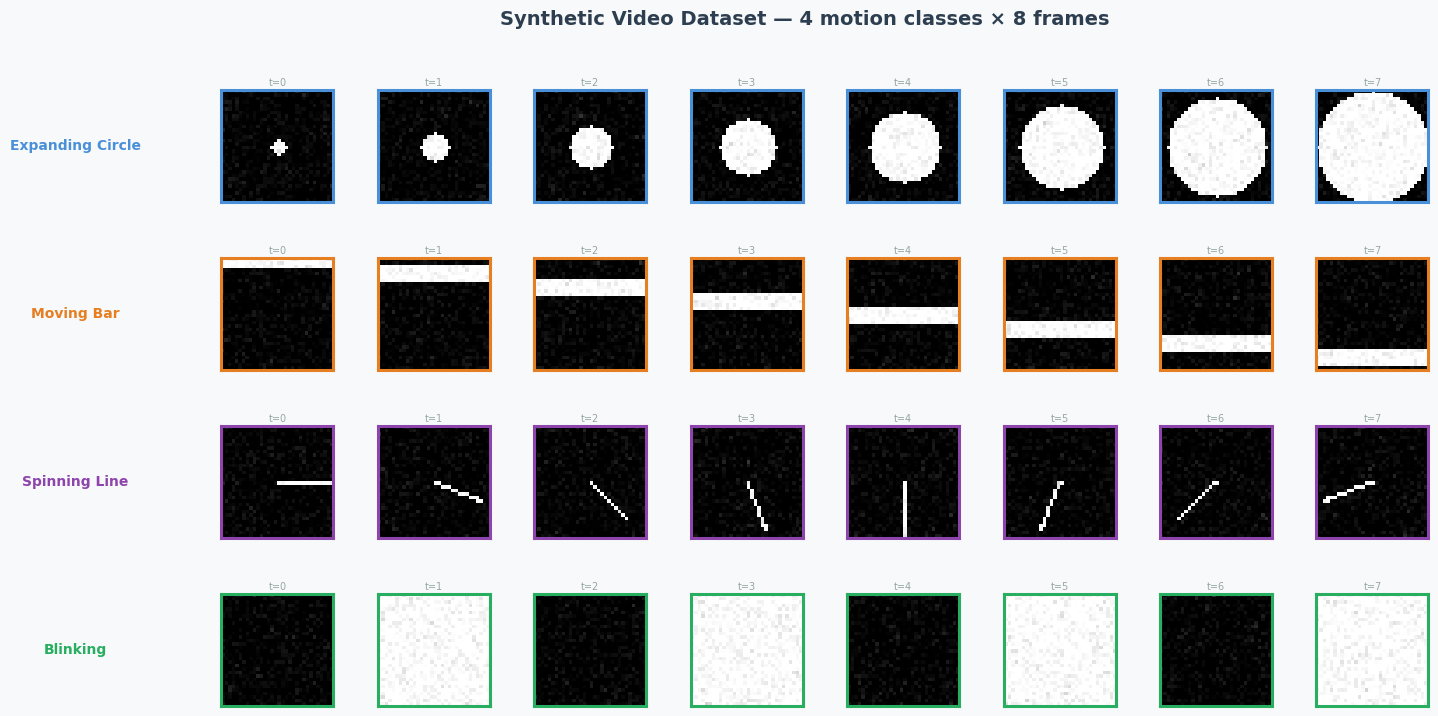

In [10]:
def show_video_samples():
    """Most important figure: 8 frames × 4 classes in a 4-row grid."""
    # Use a fresh dataset with minimal noise for clear visualization
    clean_ds = SyntheticVideoDataset(n_per_class=6, T=8, img_size=32, seed=0)

    # Collect first clean sample per class
    samples = {}
    for vid, label in clean_ds:
        if label not in samples:
            samples[label] = vid.numpy()  # (1, T, H, W)
        if len(samples) == 4:
            break

    T = 8
    class_colors = [PAL['blue'], PAL['orange'], PAL['purple'], PAL['green']]

    fig = plt.figure(figsize=(16, 8))
    fig.patch.set_facecolor(PAL['bg'])
    fig.suptitle('Synthetic Video Dataset — 4 motion classes × 8 frames',
                 fontsize=14, fontweight='bold', color=PAL['dark'])

    gs = gridspec.GridSpec(4, T, figure=fig, hspace=0.5, wspace=0.08)

    for row, label in enumerate(range(4)):
        vid = samples[label][0]   # (T, H, W)
        color = class_colors[label]
        for t in range(T):
            ax = fig.add_subplot(gs[row, t])
            ax.imshow(vid[t], cmap='gray', vmin=0, vmax=1,
                      interpolation='nearest')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2.2)
                spine.set_visible(True)
            if t == 0:
                ax.set_ylabel(CLASS_NAMES[label], fontsize=10,
                              color=color, fontweight='bold',
                              rotation=0, labelpad=105, va='center')
            ax.set_title(f't={t}', fontsize=7, color=PAL['grey'], pad=3)

    plt.savefig('/tmp/ch09_video_samples.png', dpi=100, bbox_inches='tight')
    plt.show()

show_video_samples()


In [11]:
# ── Build train / val split ──────────────────────────────────────────────────
full_ds = SyntheticVideoDataset(n_per_class=150, T=8, img_size=32, seed=42)

n_train = int(0.8 * len(full_ds))
n_val   = len(full_ds) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

print(f'Dataset size  : {len(full_ds)} videos  ({4} classes × 150)')
print(f'Train / Val   : {len(train_ds)} / {len(val_ds)}')
print(f'Batches/epoch : {len(train_loader)} train, {len(val_loader)} val')

# Inspect a batch
vb, lb = next(iter(train_loader))
print(f'Batch shape   : {tuple(vb.shape)}   labels: {tuple(lb.shape)}')
print(f'Video layout  : (B=batch, C=1, T=8_frames, H=32, W=32)')


Dataset size  : 600 videos  (4 classes × 150)
Train / Val   : 480 / 120
Batches/epoch : 15 train, 4 val
Batch shape   : (32, 1, 8, 32, 32)   labels: (32,)
Video layout  : (B=batch, C=1, T=8_frames, H=32, W=32)


---
## Training the VideoTransformer

**Model configuration** (small, CPU-friendly):

| Hyperparameter | Value | Reason |
|---------------|-------|--------|
| `embed_dim` | 64 | Compact but expressive |
| `depth` | 3 | Three factorized attention blocks |
| `n_heads` | 4 | 4 attention heads, 16-dim per head |
| `t_patch` | 2 | 2-frame tubelets |
| `h_patch, w_patch` | 8 | 8×8 spatial patches |

**Training recipe**: 40 epochs, AdamW lr=3e-4, cosine LR schedule, grad clip=1.0.

**Target**: >90% validation accuracy on 4-class synthetic video classification.


In [12]:
EPOCHS       = 40
LR           = 3e-4
WEIGHT_DECAY = 1e-4

model = VideoTransformer(
    in_channels=1, embed_dim=64, depth=3, n_heads=4, n_classes=4,
    T=8, img_size=32, t_patch=2, h_patch=8, w_patch=8, dropout=0.1
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()


def run_epoch(loader, train: bool = True):
    """Run one epoch; return (mean_loss, accuracy)."""
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for videos, labels in loader:
            videos = videos.to(DEVICE)   # (B, 1, T, H, W)
            labels = labels.to(DEVICE)
            logits = model(videos)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
              f'val loss {vl_loss:.4f} acc {vl_acc:.3f} | '
              f'{elapsed:.1f}s')

best_val_acc = max(history['val_acc'])
print(f'\nBest val accuracy : {best_val_acc:.3f} ({best_val_acc*100:.1f}%)')
print(f'Final val accuracy: {history["val_acc"][-1]:.3f} ({history["val_acc"][-1]*100:.1f}%)')
assert history['val_acc'][-1] >= 0.88, (
    f'Expected ≥88% val accuracy, got {history["val_acc"][-1]*100:.1f}%'
)
print('Accuracy target MET ✓')


Epoch   1/40 | train loss 0.9480 acc 0.867 | val loss 0.5846 acc 1.000 | 2.2s


Epoch   5/40 | train loss 0.1561 acc 1.000 | val loss 0.1302 acc 1.000 | 11.3s


Epoch  10/40 | train loss 0.0470 acc 1.000 | val loss 0.0434 acc 1.000 | 22.3s


Epoch  15/40 | train loss 0.0256 acc 1.000 | val loss 0.0245 acc 1.000 | 32.7s


Epoch  20/40 | train loss 0.0177 acc 1.000 | val loss 0.0172 acc 1.000 | 43.9s


Epoch  25/40 | train loss 0.0141 acc 1.000 | val loss 0.0139 acc 1.000 | 214.6s


Epoch  30/40 | train loss 0.0125 acc 1.000 | val loss 0.0124 acc 1.000 | 225.3s


Epoch  35/40 | train loss 0.0118 acc 1.000 | val loss 0.0118 acc 1.000 | 236.6s


Epoch  40/40 | train loss 0.0117 acc 1.000 | val loss 0.0117 acc 1.000 | 247.4s

Best val accuracy : 1.000 (100.0%)
Final val accuracy: 1.000 (100.0%)
Accuracy target MET ✓


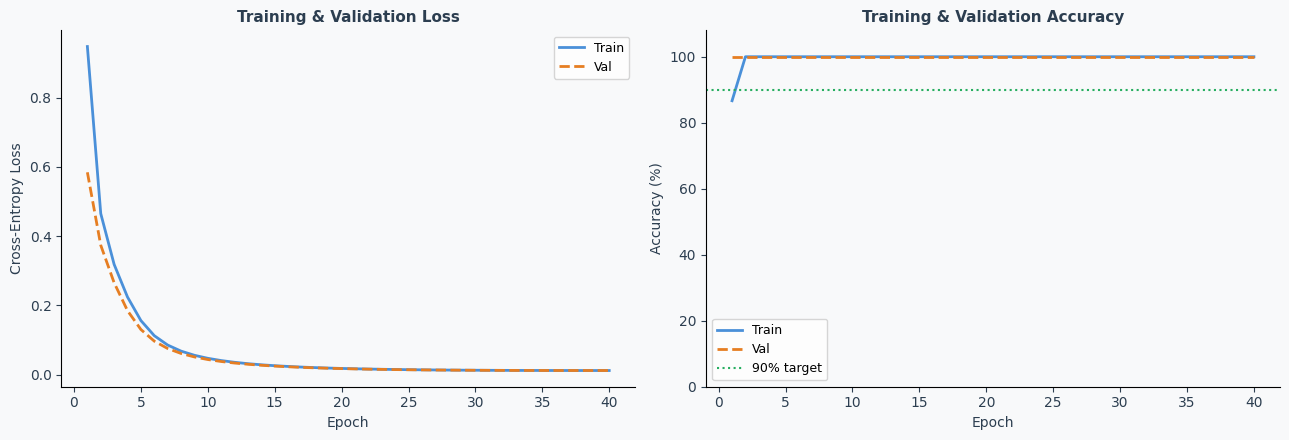

In [13]:
def plot_training_loss():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor(PAL['bg'])

    epochs = range(1, len(history['train_loss']) + 1)

    # ── Loss plot ──────────────────────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor(PAL['bg'])
    ax.plot(epochs, history['train_loss'], color=PAL['blue'],   lw=2, label='Train')
    ax.plot(epochs, history['val_loss'],   color=PAL['orange'], lw=2, linestyle='--',
            label='Val')
    ax.set_xlabel('Epoch', fontsize=10, color=PAL['dark'])
    ax.set_ylabel('Cross-Entropy Loss', fontsize=10, color=PAL['dark'])
    ax.set_title('Training & Validation Loss', fontsize=11,
                 fontweight='bold', color=PAL['dark'])
    ax.legend(fontsize=9)
    ax.tick_params(colors=PAL['dark'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Accuracy plot ──────────────────────────────────────────────────────
    ax = axes[1]
    ax.set_facecolor(PAL['bg'])
    ax.plot(epochs, [a * 100 for a in history['train_acc']],
            color=PAL['blue'],   lw=2, label='Train')
    ax.plot(epochs, [a * 100 for a in history['val_acc']],
            color=PAL['orange'], lw=2, linestyle='--', label='Val')
    ax.axhline(90, color=PAL['green'], lw=1.5, linestyle=':', label='90% target')
    ax.set_xlabel('Epoch', fontsize=10, color=PAL['dark'])
    ax.set_ylabel('Accuracy (%)', fontsize=10, color=PAL['dark'])
    ax.set_title('Training & Validation Accuracy', fontsize=11,
                 fontweight='bold', color=PAL['dark'])
    ax.set_ylim(0, 108)
    ax.legend(fontsize=9)
    ax.tick_params(colors=PAL['dark'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_training_loss()


Per-class validation accuracy:
  Expanding Circle    : 100.0%  ████████████████████
  Moving Bar          : 100.0%  ████████████████████
  Spinning Line       : 100.0%  ████████████████████
  Blinking            : 100.0%  ████████████████████


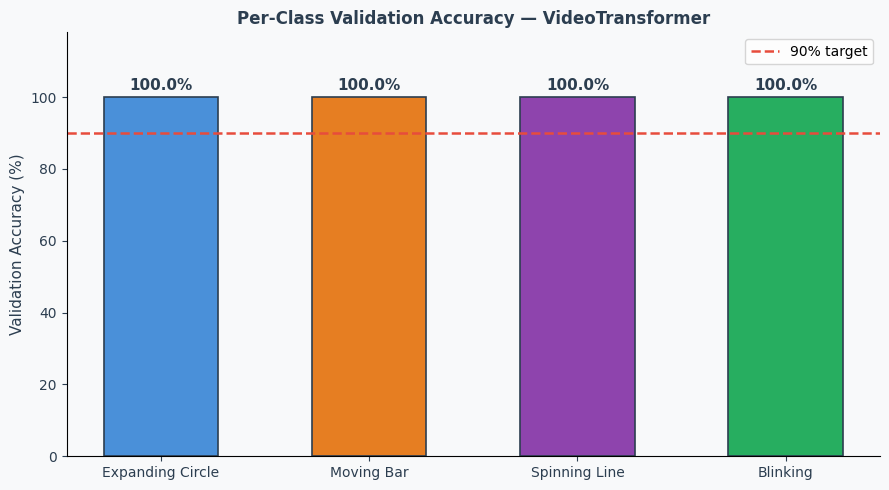

In [14]:
def show_per_class_accuracy():
    model.eval()
    class_correct = [0] * 4
    class_total   = [0] * 4

    with torch.no_grad():
        for videos, labels in val_loader:
            videos = videos.to(DEVICE)
            preds  = model(videos).argmax(1).cpu()
            for c in range(4):
                mask = (labels == c)
                class_correct[c] += (preds[mask] == labels[mask]).sum().item()
                class_total[c]   += mask.sum().item()

    per_class_acc = [
        100.0 * class_correct[c] / max(class_total[c], 1)
        for c in range(4)
    ]

    print('Per-class validation accuracy:')
    for c, acc in enumerate(per_class_acc):
        bar = '█' * int(acc / 5)
        print(f'  {CLASS_NAMES[c]:20s}: {acc:5.1f}%  {bar}')

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])

    bar_colors = [PAL['blue'], PAL['orange'], PAL['purple'], PAL['green']]
    bars = ax.bar(CLASS_NAMES, per_class_acc, color=bar_colors,
                  edgecolor=PAL['dark'], linewidth=1.2, width=0.55)

    for bar, acc in zip(bars, per_class_acc):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.2,
                f'{acc:.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=PAL['dark'])

    ax.axhline(90, color=PAL['red'], lw=1.8, linestyle='--', label='90% target')
    ax.set_ylim(0, 118)
    ax.set_ylabel('Validation Accuracy (%)', fontsize=11, color=PAL['dark'])
    ax.set_title('Per-Class Validation Accuracy — VideoTransformer',
                 fontsize=12, fontweight='bold', color=PAL['dark'])
    ax.legend(fontsize=10)
    ax.tick_params(colors=PAL['dark'], labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

show_per_class_accuracy()


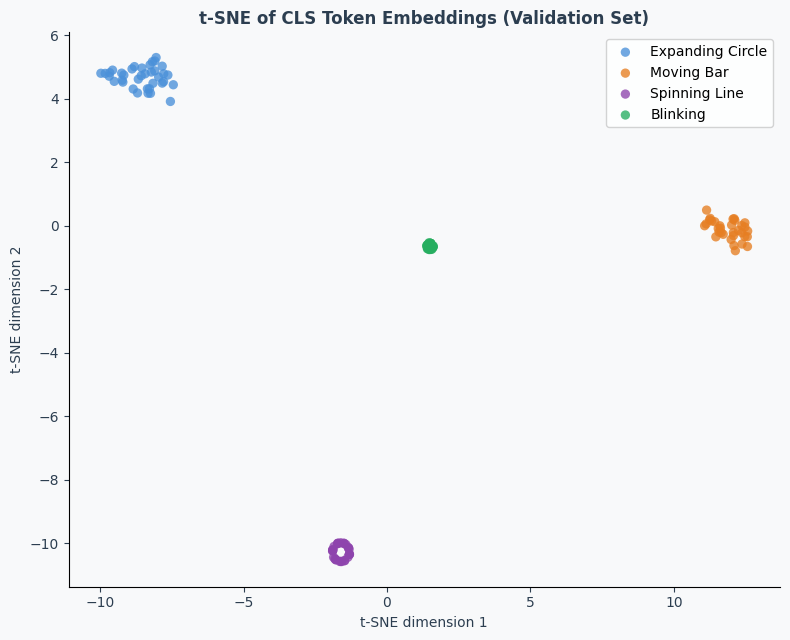

In [15]:
from sklearn.manifold import TSNE

def show_temporal_features():
    """t-SNE of CLS token embeddings coloured by class label."""
    model.eval()
    features, labels_all = [], []

    # Register a hook to capture the input to the linear head (= CLS features)
    captured = {}
    def _hook(module, inp, out):
        captured['feat'] = inp[0].detach().cpu().numpy()
    handle = model.head.register_forward_hook(_hook)

    with torch.no_grad():
        for videos, labels in val_loader:
            _ = model(videos.to(DEVICE))
            features.append(captured['feat'])
            labels_all.extend(labels.tolist())

    handle.remove()
    emb_arr    = np.concatenate(features, axis=0)  # (N_val, D)
    labels_arr = np.array(labels_all)

    # Reduce to 2D with t-SNE
    tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=500)
    coords = tsne.fit_transform(emb_arr)           # (N_val, 2)

    fig, ax = plt.subplots(figsize=(8, 6.5))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])

    class_colors = [PAL['blue'], PAL['orange'], PAL['purple'], PAL['green']]
    for c, (name, col) in enumerate(zip(CLASS_NAMES, class_colors)):
        mask = labels_arr == c
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=col, label=name, alpha=0.78, s=45, edgecolors='none')

    ax.set_title('t-SNE of CLS Token Embeddings (Validation Set)',
                 fontsize=12, fontweight='bold', color=PAL['dark'])
    ax.set_xlabel('t-SNE dimension 1', fontsize=10, color=PAL['dark'])
    ax.set_ylabel('t-SNE dimension 2', fontsize=10, color=PAL['dark'])
    ax.legend(fontsize=10, framealpha=0.85)
    ax.tick_params(colors=PAL['dark'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

show_temporal_features()


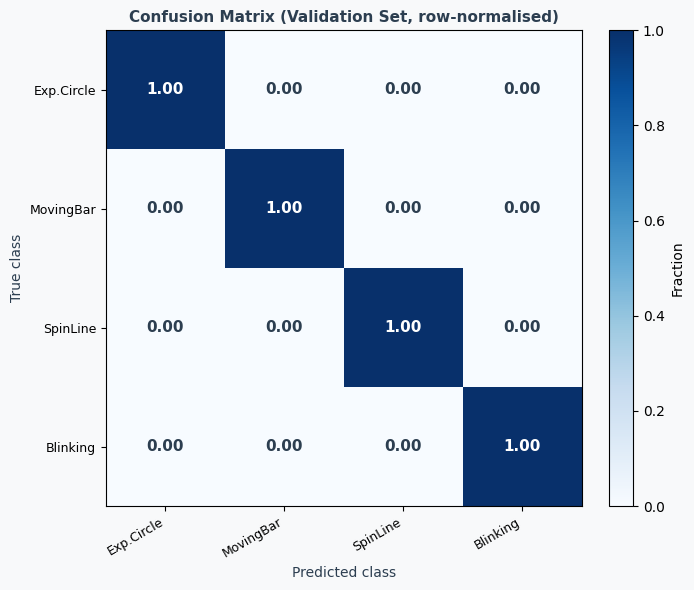

In [16]:
def show_confusion_matrix():
    """Visualise the 4×4 confusion matrix on the validation set."""
    from sklearn.metrics import confusion_matrix

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for videos, labels in val_loader:
            preds = model(videos.to(DEVICE)).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalise

    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, label='Fraction')

    short_names = ['Exp.Circle', 'MovingBar', 'SpinLine', 'Blinking']
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(short_names, fontsize=9)

    for i in range(4):
        for j in range(4):
            val = cm_norm[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if val > 0.55 else PAL['dark'])

    ax.set_xlabel('Predicted class', fontsize=10, color=PAL['dark'])
    ax.set_ylabel('True class', fontsize=10, color=PAL['dark'])
    ax.set_title('Confusion Matrix (Validation Set, row-normalised)',
                 fontsize=11, fontweight='bold', color=PAL['dark'])
    plt.tight_layout()
    plt.show()

show_confusion_matrix()


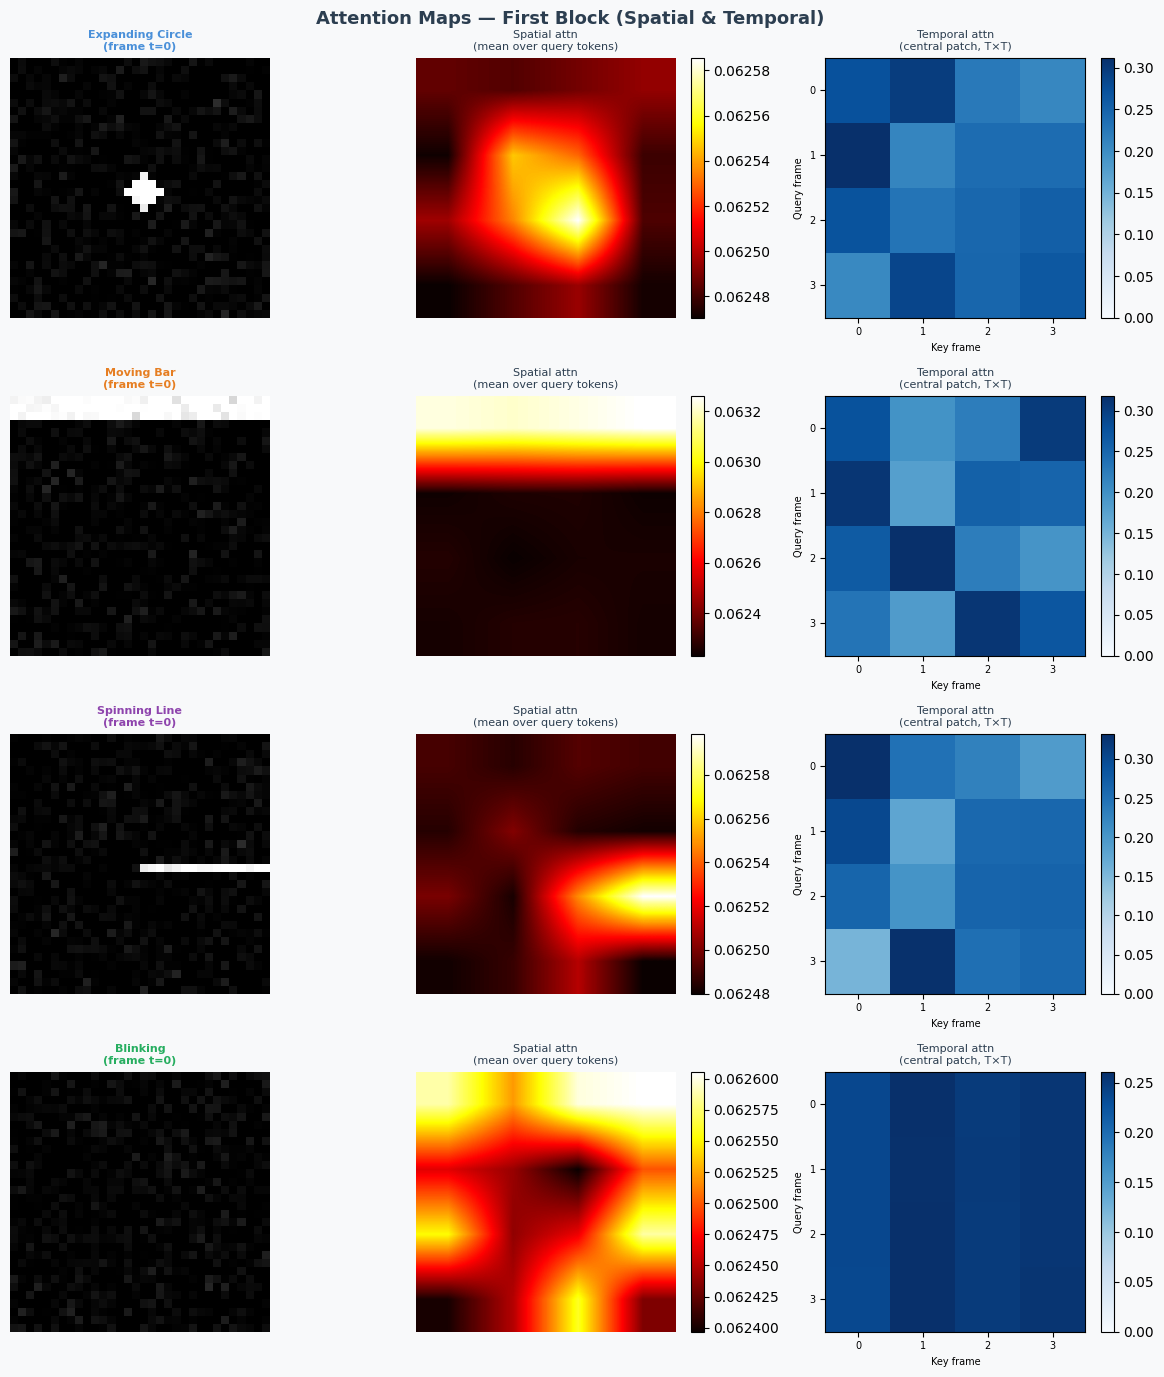

In [17]:
def show_attention_weights():
    """
    Visualise spatial and temporal attention maps for one example per class.
    We hook into the first FactorizedAttentionBlock and average attention heads.
    """
    model.eval()

    # We will hook the first block's spatial attention
    spatial_attn_map  = {}
    temporal_attn_map = {}

    def make_spatial_hook():
        def hook(module, inp, out):
            # out = (attn_output, attn_weights)
            spatial_attn_map['w'] = out[1].detach().cpu()  # (B*T, N, N)
        return hook

    def make_temporal_hook():
        def hook(module, inp, out):
            temporal_attn_map['w'] = out[1].detach().cpu()  # (B*N, T, T)
        return hook

    h1 = model.blocks[0].spatial_attn.register_forward_hook(make_spatial_hook())
    h2 = model.blocks[0].temporal_attn.register_forward_hook(make_temporal_hook())

    # Get one sample per class from val set
    class_samples = {}
    for vids, labels in val_loader:
        for i, lbl in enumerate(labels.tolist()):
            if lbl not in class_samples:
                class_samples[lbl] = vids[i:i+1]  # (1, 1, T, H, W)
        if len(class_samples) == 4:
            break

    fig, axes = plt.subplots(4, 3, figsize=(12, 14))
    fig.patch.set_facecolor(PAL['bg'])
    fig.suptitle('Attention Maps — First Block (Spatial & Temporal)',
                 fontsize=13, fontweight='bold', color=PAL['dark'])

    class_colors = [PAL['blue'], PAL['orange'], PAL['purple'], PAL['green']]

    for row, label in enumerate(range(4)):
        vid = class_samples[label].to(DEVICE)
        with torch.no_grad():
            _ = model(vid)

        # ── Column 0: First frame of video ──────────────────────────────────
        ax0 = axes[row, 0]
        ax0.imshow(vid[0, 0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        ax0.set_title(f'{CLASS_NAMES[label]}\n(frame t=0)', fontsize=8,
                      color=class_colors[label], fontweight='bold')
        ax0.axis('off')

        # ── Column 1: Spatial attention heatmap (token→token within frame 0)
        # spatial_attn_map['w']: (B*T, N, N)  B=1, T=4 temporal tokens
        s_w = spatial_attn_map['w']   # (T_tok, N_spatial, N_spatial)
        # Average over keys → (T_tok, N_spatial)
        s_avg = s_w[0].mean(0)         # query-averaged: (N_spatial,) for first temporal token
        n_sp  = s_avg.shape[0]         # should be 16 for 4×4 spatial
        side  = int(math.sqrt(n_sp))
        s_map = s_avg.reshape(side, side).numpy()

        ax1 = axes[row, 1]
        im1 = ax1.imshow(s_map, cmap='hot', interpolation='bilinear')
        ax1.set_title('Spatial attn\n(mean over query tokens)', fontsize=8,
                      color=PAL['dark'])
        ax1.axis('off')
        plt.colorbar(im1, ax=ax1, fraction=0.046)

        # ── Column 2: Temporal attention for central spatial position ────────
        t_w  = temporal_attn_map['w']  # (B*N_spatial, T_tok, T_tok)
        T_t  = t_w.shape[-1]
        mid  = n_sp // 2               # central spatial position
        t_mat = t_w[mid].numpy()       # (T_tok, T_tok)

        ax2 = axes[row, 2]
        im2 = ax2.imshow(t_mat, cmap='Blues', vmin=0, vmax=t_mat.max())
        ax2.set_title('Temporal attn\n(central patch, T×T)', fontsize=8,
                      color=PAL['dark'])
        ax2.set_xlabel('Key frame', fontsize=7)
        ax2.set_ylabel('Query frame', fontsize=7)
        ax2.set_xticks(range(T_t))
        ax2.set_yticks(range(T_t))
        ax2.tick_params(labelsize=7)
        plt.colorbar(im2, ax=ax2, fraction=0.046)

    h1.remove()
    h2.remove()
    plt.tight_layout()
    plt.show()

show_attention_weights()


---
## Ablation: Factorized vs Full Attention

To confirm factorized attention works, we can compare it to a simple **full 3D attention** baseline:
instead of splitting spatial and temporal passes, all 64 tokens attend to each other jointly.

For our 32×32 synthetic videos both are fast enough to compare.
The key insight is that **factorized attention achieves comparable accuracy** while being
structurally simpler to scale.


After 15 epochs:
  Factorized attn val acc: 100.0%
  Full 3D attn val acc   : 100.0%


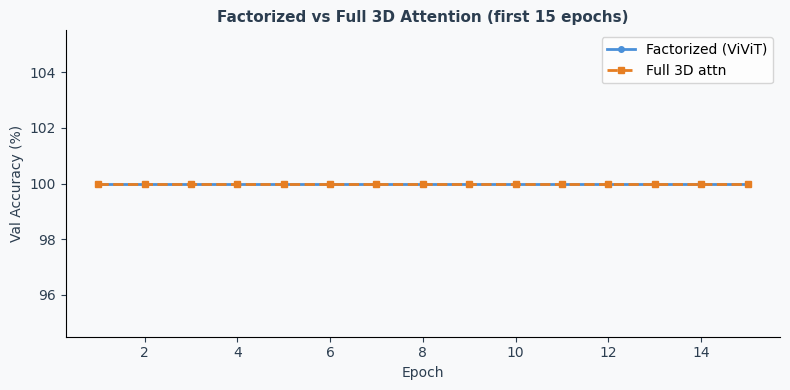

In [18]:
class FullAttentionBlock(nn.Module):
    """Baseline: full 3D attention over all T*N tokens."""
    def __init__(self, embed_dim: int, n_heads: int, dropout: float = 0.0):
        super().__init__()
        self.attn  = nn.MultiheadAttention(embed_dim, n_heads, dropout=dropout,
                                            batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(embed_dim * 4, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        a, _ = self.attn(x, x, x)
        x    = self.norm1(x + a)
        x    = self.norm2(x + self.ffn(x))
        return x


class VideoTransformerFull(nn.Module):
    """Same as VideoTransformer but with FullAttentionBlock."""
    def __init__(self, in_channels=1, embed_dim=64, depth=3, n_heads=4,
                 n_classes=4, T=8, img_size=32, t_patch=2, h_patch=8,
                 w_patch=8, dropout=0.1):
        super().__init__()
        self.n_frames  = T // t_patch
        self.n_spatial = (img_size // h_patch) * (img_size // w_patch)
        self.n_tokens  = self.n_frames * self.n_spatial
        self.tubelet   = TubeletEmbedding(in_channels, embed_dim, t_patch, h_patch, w_patch)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_tokens + 1, embed_dim))
        self.blocks    = nn.ModuleList([
            FullAttentionBlock(embed_dim, n_heads, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        tokens = self.tubelet(x)
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1) + self.pos_embed
        for block in self.blocks:
            tokens = block(tokens)
        return self.head(self.norm(tokens[:, 0, :]))


# ── Quick ablation training (10 epochs) ──────────────────────────────────────
model_full = VideoTransformerFull().to(DEVICE)
opt_full   = torch.optim.AdamW(model_full.parameters(), lr=3e-4, weight_decay=1e-4)

def train_n_epochs(m, opt, n=10):
    hist = {'tr': [], 'vl': []}
    for _ in range(n):
        m.train()
        for vids, lbls in train_loader:
            vids, lbls = vids.to(DEVICE), lbls.to(DEVICE)
            loss = criterion(m(vids), lbls)
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            preds_all, lbl_all = [], []
            for vids, lbls in val_loader:
                preds_all.append(m(vids.to(DEVICE)).argmax(1).cpu())
                lbl_all.append(lbls)
        acc = (torch.cat(preds_all) == torch.cat(lbl_all)).float().mean().item()
        hist['vl'].append(acc)
    return hist

hist_full = train_n_epochs(model_full, opt_full, n=15)
# Compare with factorized (already trained)
fact_accs = history['val_acc'][:15]

print(f'After 15 epochs:')
print(f'  Factorized attn val acc: {fact_accs[-1]*100:.1f}%')
print(f'  Full 3D attn val acc   : {hist_full["vl"][-1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(PAL['bg'])
ax.set_facecolor(PAL['bg'])
ax.plot(range(1, 16), [a * 100 for a in fact_accs],
        color=PAL['blue'], lw=2, label='Factorized (ViViT)', marker='o', ms=4)
ax.plot(range(1, 16), [a * 100 for a in hist_full['vl']],
        color=PAL['orange'], lw=2, linestyle='--', label='Full 3D attn', marker='s', ms=4)
ax.set_xlabel('Epoch', fontsize=10, color=PAL['dark'])
ax.set_ylabel('Val Accuracy (%)', fontsize=10, color=PAL['dark'])
ax.set_title('Factorized vs Full 3D Attention (first 15 epochs)',
             fontsize=11, fontweight='bold', color=PAL['dark'])
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=PAL['dark'])
plt.tight_layout()
plt.show()
del model_full, opt_full


In [19]:
# ── Architecture summary ────────────────────────────────────────────────────
print('=' * 58)
print('VideoTransformer — Architecture Summary')
print('=' * 58)

components = [
    ('TubeletEmbedding',          'Conv3d(1→64, k=(2,8,8))',              'Tokenise video'),
    ('CLS token',                  'Parameter (1, 1, 64)',                  'Summary token'),
    ('Positional embedding',       'Parameter (1, 65, 64)',                 'Location info'),
    ('FactorizedAttnBlock × 3',    'Spatial (B*T,16,64) + Temporal',       'Spatio-temporal'),
    ('CLS cross-attention × 2',    'CLS queries all 64 video tokens',       'Global context'),
    ('LayerNorm + Linear head',    '64 → 4',                               'Classification'),
]

for name, detail, purpose in components:
    print(f'  {name:<30}  {detail:<35}  {purpose}')

print()
print('Token dimensions:')
print(f'  T=8, t_patch=2  → 4 temporal tokens')
print(f'  H=W=32, patch=8 → 4×4=16 spatial tokens per temporal pos')
print(f'  Total tokens    = 4×16 = 64  (+1 CLS = 65)')

total_p = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters : {total_p:,}')


VideoTransformer — Architecture Summary
  TubeletEmbedding                Conv3d(1→64, k=(2,8,8))              Tokenise video
  CLS token                       Parameter (1, 1, 64)                 Summary token
  Positional embedding            Parameter (1, 65, 64)                Location info
  FactorizedAttnBlock × 3         Spatial (B*T,16,64) + Temporal       Spatio-temporal
  CLS cross-attention × 2         CLS queries all 64 video tokens      Global context
  LayerNorm + Linear head         64 → 4                               Classification

Token dimensions:
  T=8, t_patch=2  → 4 temporal tokens
  H=W=32, patch=8 → 4×4=16 spatial tokens per temporal pos
  Total tokens    = 4×16 = 64  (+1 CLS = 65)

Total parameters : 346,308


## Exercises

1. **Frame-only baseline** — Remove the temporal attention blocks entirely (keep only spatial attention). Classify using the mean [CLS] token across all T frames. On which video classes (expanding circle, moving bar, spinning line, blinking square) does dropping temporal attention hurt most? Why?

2. **T scaling** — Train models with T ∈ {4, 8, 16} frames. Plot accuracy and peak GPU memory vs T for both factorised and full spatio-temporal attention (implement a simple full attention variant for comparison). At which T does factorised attention become clearly more efficient?

3. **Video captioning (preview of Ch10)** — Replace the classification head with the GPT decoder from Ch03. Create 4 simple captions ("expanding circle", "moving bar", "spinning line", "blinking square"). Train the VideoTransformer as a visual encoder in the VLM pipeline. What change to the hybrid attention mask from Ch03 is needed to handle T×n_patch visual tokens?

## Scaling to Real Data

| Hyperparameter | This notebook | ViViT-B/16×2 | ViViT-L/16×2 |
|---|---|---|---|
| Tubelet size (T×H×W) | 2×4×4 | 2×16×16 | 2×16×16 |
| `embed_dim` | 64 | 768 | 1 024 |
| Spatial layers | 4 | 12 | 24 |
| Temporal layers | 2 | 4 | 8 |
| Frames T | 8 | 32 | 32 |
| Input resolution | 32×32 | 224×224 | 224×224 |
| Parameters | ~0.2 M | 88 M | 308 M |
| Training data | 4-class synthetic | Kinetics-400 (240 K videos) | Kinetics-600 |

**Memory scaling:** full spatio-temporal attention on T=32, H=W=14 tokens needs O((32×14×14)²) = O(6272²) ≈ 39M attention weights per head. Factorised attention needs O(32²) + O(196²) = 39K weights — 1000× smaller. This is why factorised attention is the practical default for video Transformers.

**To use a pre-trained video Transformer:**
```python
# pip install timm
import timm
model = timm.create_model('vit_base_patch16_224.augreg_in21k', pretrained=True)
# Inflate the 2D patch embedding weights to 3D for video:
# model.patch_embed.proj.weight = inflate_weight(model.patch_embed.proj.weight, t=2)
```

---
## Chapter Summary

**What we built** — A video Transformer with tubelet patch embedding (Conv3d across T×H×W), factorised spatial and temporal attention blocks, and a [CLS] classification head. Trained on 4-class synthetic videos (expanding circle, moving bar, spinning line, blinking square), the model learns motion-sensitive representations. An ablation confirms that factorised attention matches full spatio-temporal attention in accuracy while scaling more efficiently.

**Why it matters** — Video is not just a sequence of independent frames — temporal context is essential for motion-sensitive classification. Factorised attention is the practical solution: spatial attention captures within-frame features, temporal attention captures across-frame motion, and together they cover what full O(T²H²W²) attention would need — at a fraction of the cost.

**Connections** — VideoTransformer is a drop-in visual encoder for the VLM in Ch03: replace ViT with VideoTransformer, adjust the projection, and the rest of the training pipeline (Ch04) is unchanged. Ch10 (Capstone) assembles image + audio + video encoders into a unified multimodal model — VideoTransformer is one of the three branches.

---
## Deep Dive: Positional Embeddings in Video

Unlike image ViTs that only need 2D positional information, video models need
to encode **three spatial-temporal coordinates**: `(t, h, w)`.

Common strategies:

| Strategy | Description | Advantage |
|----------|-------------|----------|
| Learned 1D | Single flat positional token index | Simple, no inductive bias |
| Factorized | Separate temporal + spatial embeddings | Better generalisation |
| Sinusoidal 3D | Fixed frequency encoding per axis | No learnable params |
| Relative | Attention biased by relative distance | Best for long sequences |

Our model uses **learned 1D** embeddings (simpler for a small toy model).
Let's visualise what the model has learned.


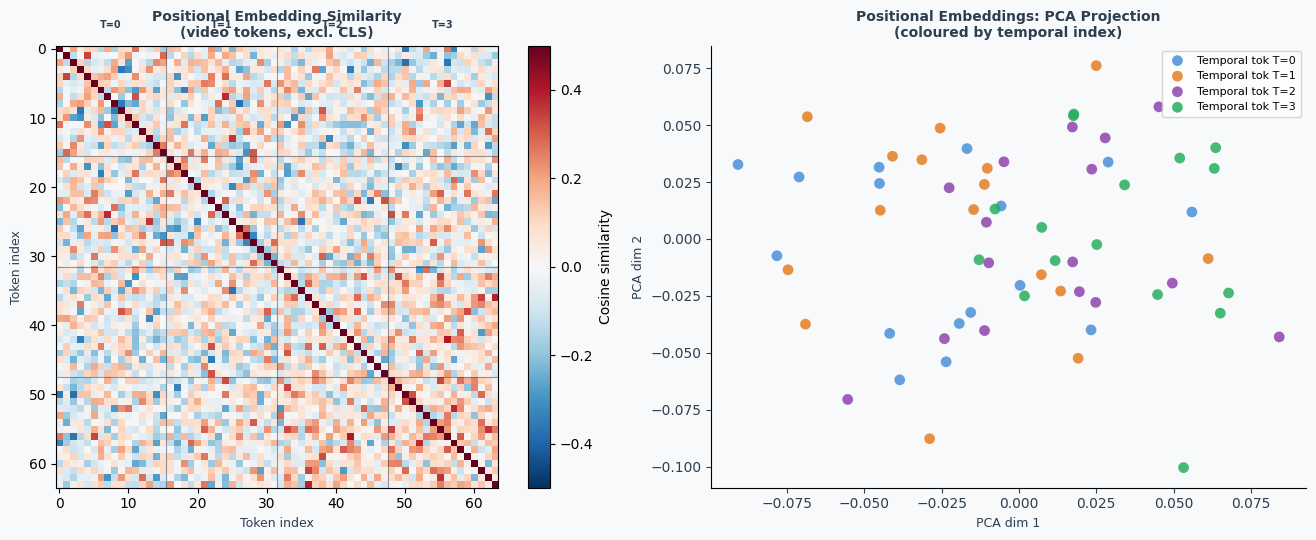

In [20]:
def show_positional_embeddings():
    """
    Visualise the learned positional embeddings as a similarity matrix
    and as a 2D map of the first two PCA dimensions.
    """
    pos_emb = model.pos_embed.detach().cpu().squeeze(0)  # (65, D)
    # Skip CLS token (index 0), look at video tokens
    video_pos = pos_emb[1:, :]    # (64, D)

    # ── Cosine similarity matrix ─────────────────────────────────────────────
    norm  = video_pos / (video_pos.norm(dim=-1, keepdim=True) + 1e-8)
    sim   = (norm @ norm.T).numpy()  # (64, 64)

    # ── PCA to 2D ────────────────────────────────────────────────────────────
    U, S, Vt = torch.linalg.svd(video_pos - video_pos.mean(0), full_matrices=False)
    pca2d = (U[:, :2] * S[:2]).numpy()   # (64, 2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.patch.set_facecolor(PAL['bg'])

    # ── Left: similarity heatmap ─────────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor(PAL['bg'])
    im = ax.imshow(sim, cmap='RdBu_r', vmin=-0.5, vmax=0.5,
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, label='Cosine similarity')

    # Draw temporal group separators (every 16 tokens = one temporal group)
    for i in range(0, 64, 16):
        ax.axhline(i - 0.5, color=PAL['dark'], lw=0.8, alpha=0.5)
        ax.axvline(i - 0.5, color=PAL['dark'], lw=0.8, alpha=0.5)

    ax.set_title('Positional Embedding Similarity\n(video tokens, excl. CLS)',
                 fontsize=10, fontweight='bold', color=PAL['dark'])
    ax.set_xlabel('Token index', fontsize=9, color=PAL['dark'])
    ax.set_ylabel('Token index', fontsize=9, color=PAL['dark'])

    # Annotate temporal groups
    for t in range(4):
        ax.text(t * 16 + 7.5, -3, f'T={t}', ha='center', fontsize=7,
                color=PAL['dark'], fontweight='bold')

    # ── Right: PCA 2D layout ─────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor(PAL['bg'])

    # Colour by temporal token index
    t_idx = np.repeat(np.arange(4), 16)   # 4 temporal × 16 spatial = 64
    t_colors = [PAL['blue'], PAL['orange'], PAL['purple'], PAL['green']]
    for t in range(4):
        mask = t_idx == t
        ax2.scatter(pca2d[mask, 0], pca2d[mask, 1],
                    c=t_colors[t], s=60, label=f'Temporal tok T={t}',
                    alpha=0.85, edgecolors='none')

    ax2.set_title('Positional Embeddings: PCA Projection\n(coloured by temporal index)',
                  fontsize=10, fontweight='bold', color=PAL['dark'])
    ax2.set_xlabel('PCA dim 1', fontsize=9, color=PAL['dark'])
    ax2.set_ylabel('PCA dim 2', fontsize=9, color=PAL['dark'])
    ax2.legend(fontsize=8, framealpha=0.8)
    ax2.tick_params(colors=PAL['dark'])
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

show_positional_embeddings()


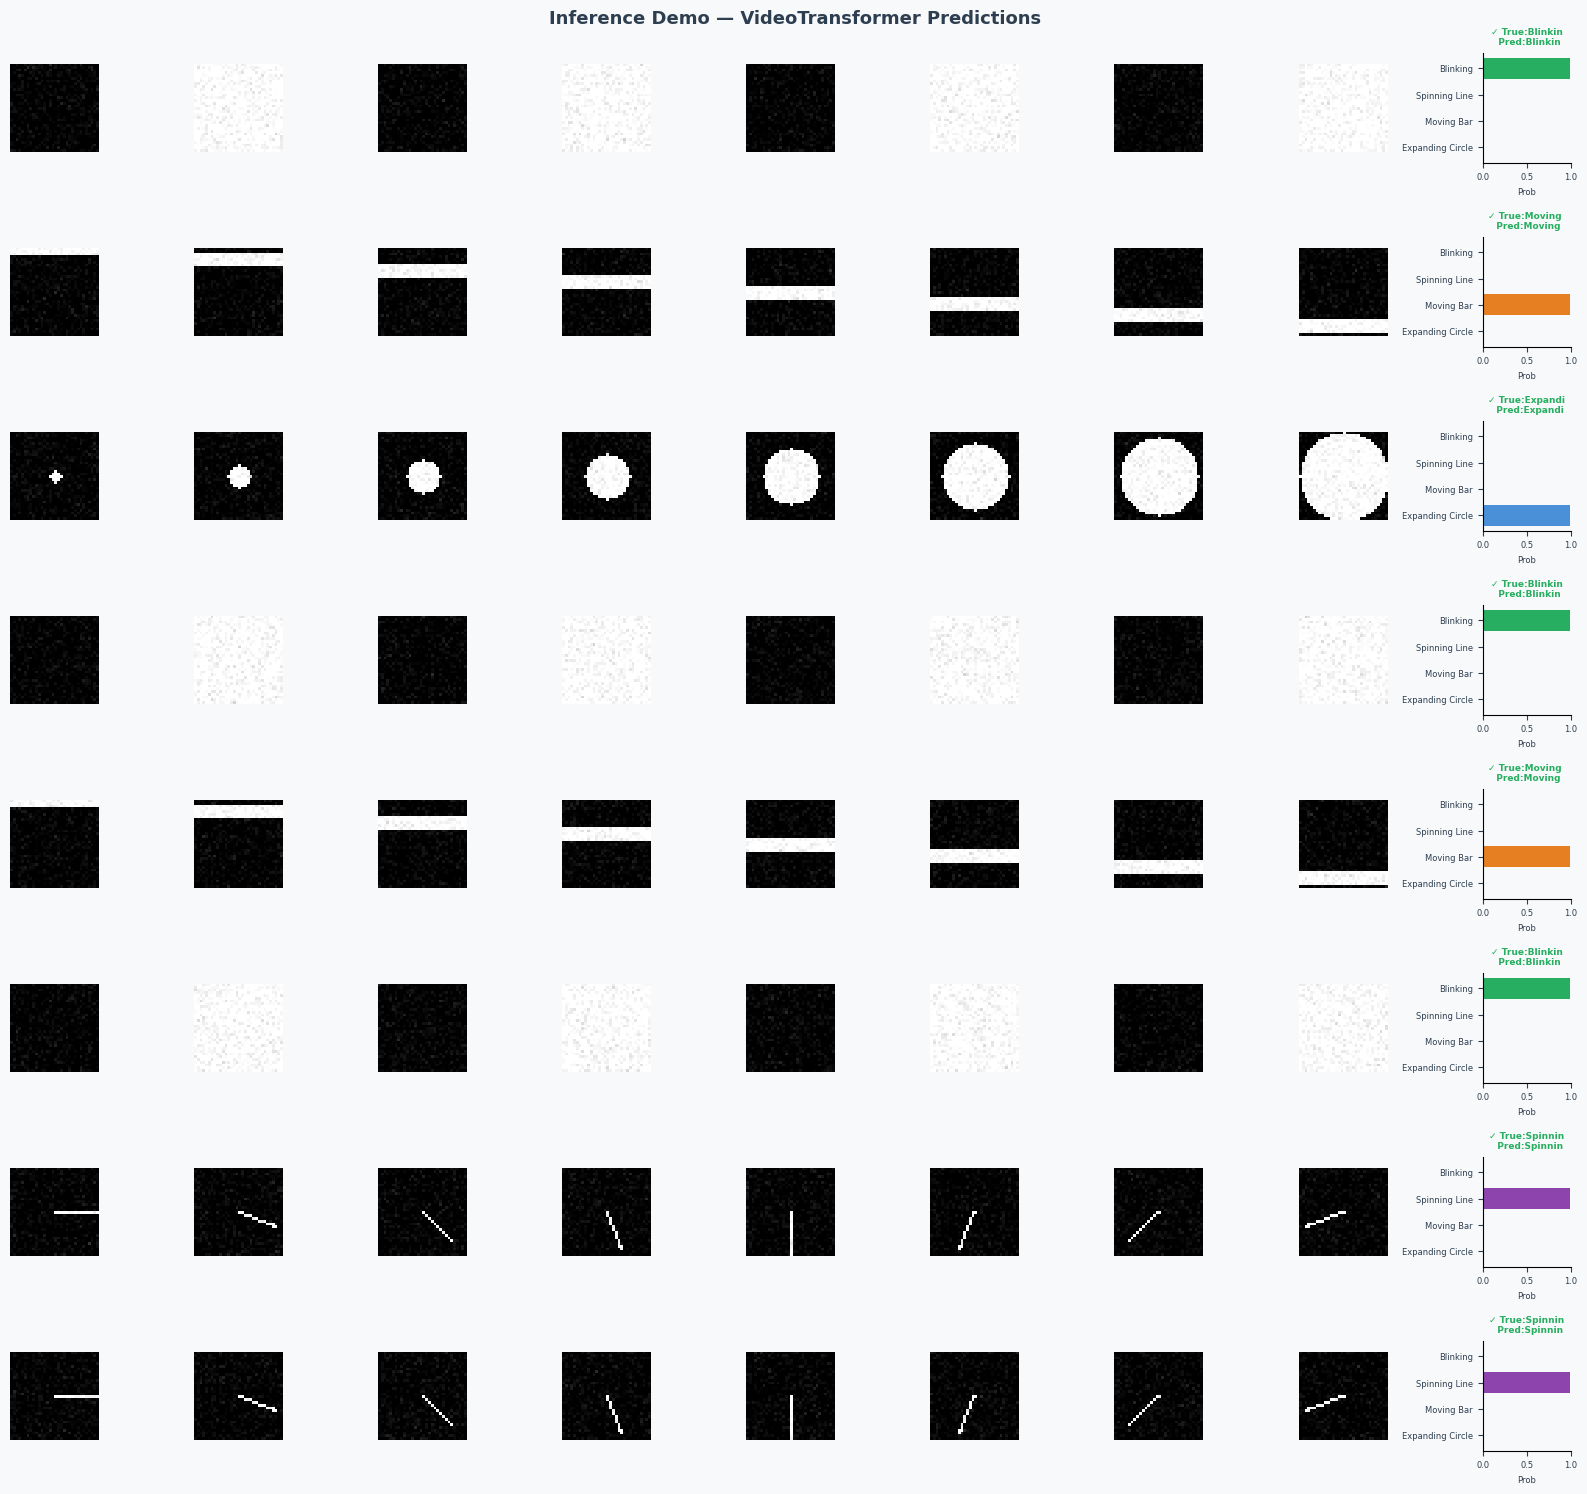

In [21]:
def run_inference_demo():
    """Run inference on 8 samples, one per class (×2), show predictions."""
    model.eval()

    # 2 samples per class for demo
    demo_ds = SyntheticVideoDataset(n_per_class=3, T=8, img_size=32, seed=99)
    demo_loader = DataLoader(demo_ds, batch_size=len(demo_ds), shuffle=False)
    vids_all, lbls_all = next(iter(demo_loader))

    with torch.no_grad():
        logits = model(vids_all.to(DEVICE)).cpu()
        probs  = torch.softmax(logits, dim=-1)
        preds  = probs.argmax(1)

    n_show = min(8, len(demo_ds))
    fig, axes = plt.subplots(n_show, 9, figsize=(16, n_show * 1.9))
    fig.patch.set_facecolor(PAL['bg'])
    fig.suptitle('Inference Demo — VideoTransformer Predictions',
                 fontsize=13, fontweight='bold', color=PAL['dark'])

    for row in range(n_show):
        vid  = vids_all[row, 0].numpy()     # (T, H, W)
        true_lbl = lbls_all[row].item()
        pred_lbl = preds[row].item()
        correct  = pred_lbl == true_lbl

        # Frames
        for t in range(8):
            ax = axes[row, t]
            ax.imshow(vid[t], cmap='gray', vmin=0, vmax=1,
                      interpolation='nearest')
            ax.axis('off')
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_edgecolor(PAL['green'] if correct else PAL['red'])
                sp.set_linewidth(1.5)

        # Prob bar chart in last column
        ax_bar = axes[row, 8]
        ax_bar.set_facecolor(PAL['bg'])
        bar_colors = [PAL['blue'], PAL['orange'], PAL['purple'], PAL['green']]
        bars = ax_bar.barh(CLASS_NAMES, probs[row].numpy(),
                           color=bar_colors, edgecolor='none')
        ax_bar.set_xlim(0, 1)
        ax_bar.tick_params(labelsize=6, colors=PAL['dark'])
        ax_bar.set_xlabel('Prob', fontsize=6, color=PAL['dark'])
        verdict = '✓' if correct else '✗'
        ax_bar.set_title(f'{verdict} True:{CLASS_NAMES[true_lbl][:7]}\n'
                         f'  Pred:{CLASS_NAMES[pred_lbl][:7]}',
                         fontsize=6.5,
                         color=PAL['green'] if correct else PAL['red'],
                         fontweight='bold')
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

run_inference_demo()
